# Correlation of pairwise G-Eval judgments

Loads **checkpoint JSONL** files (same layout as the pairwise pipeline: one file per judge × dimension under `.deepeval/geval_judgment_checkpoints/`).

- **Inter-judge agreement (per dimension):** same document, same model pair, same summary-pair hash — correlate encoded outcomes across LLM judges (Pearson & Spearman on scores: left wins = 1, right wins = −1, tie = 0).
- **Inter-dimension agreement (per judge):** same comparison across criteria — correlation matrix over dimensions.

Run with the **repository root** as the working directory. Adjust `EXCLUDE_API_ERRORS` if you want to drop rows whose rationale starts with `[api_error]`.

**Plots:** publication-style **RdBu_r** heatmaps (−1…1), white cell borders, outlined annotations, and a bar summary. Set `SAVE_FIGURES = True` in the first code cell to export PNG under `.deepeval/geval_exports/images/`.

In [ ]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pairwise_eval.config import EVAL_DIMENSIONS, GEVAL_CHECKPOINT_DIR, JUDGES, REPO_ROOT


def _apply_publication_matplotlib_style() -> None:
    """Sans-serif, high-DPI export defaults, minimal axes (used by heatmaps and bar plots)."""
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.transparent": False,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.04,
            "figure.facecolor": "white",
            "axes.facecolor": "#fafafa",
            "axes.edgecolor": "#2a2a2a",
            "axes.linewidth": 0.9,
            "axes.labelcolor": "#1a1a1a",
            "axes.titlepad": 10,
            "axes.grid": False,
            "text.color": "#1a1a1a",
            "font.family": "sans-serif",
            "font.sans-serif": [
                "Helvetica Neue",
                "Arial",
                "DejaVu Sans",
                "Bitstream Vera Sans",
                "sans-serif",
            ],
            "font.size": 10,
            "axes.titlesize": 12,
            "axes.titleweight": "600",
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "xtick.major.width": 0.5,
            "ytick.major.width": 0.5,
            "legend.frameon": False,
        }
    )


_apply_publication_matplotlib_style()

# Set True to write PNG under FIGURES_DIR after each figure (filenames from plot titles).
SAVE_FIGURES = True
FIGURES_DIR = REPO_ROOT / ".deepeval" / "geval_exports" / "images"

CHECKPOINT_DIR = (
    GEVAL_CHECKPOINT_DIR
    if GEVAL_CHECKPOINT_DIR is not None
    else REPO_ROOT / ".deepeval" / "geval_judgment_checkpoints"
)
JUDGES_USED: tuple[str, ...] = tuple(JUDGES)
DIMENSIONS: tuple[str, ...] = tuple(EVAL_DIMENSIONS)

EXCLUDE_API_ERRORS = True

print("Checkpoint dir:", CHECKPOINT_DIR.resolve())
print("Judges:", list(JUDGES_USED))
print("Dimensions:", list(DIMENSIONS))


Checkpoint dir: /Users/baharehfatemi/Desktop/demokratibasen/.deepeval/geval_judgment_checkpoints
Judges: ['google/gemma-3-4b', 'gpt-3.5-turbo']
Dimensions: ['faithfulness', 'correctness', 'completeness', 'newsworthiness']


In [36]:
def _safe_stem(judge_id: str) -> str:
    return judge_id.replace("\\", "__").replace("/", "__")


def choice_side_to_score(side: object) -> float:
    if side == "left":
        return 1.0
    if side == "right":
        return -1.0
    return 0.0


def load_judgments_long(
    checkpoint_dir: Path,
    judges: tuple[str, ...],
    dimensions: tuple[str, ...],
    *,
    exclude_api_errors: bool,
) -> pd.DataFrame:
    """One row per judgment with parsed stable-key fields."""
    rows: list[dict] = []
    for judge in judges:
        stem = _safe_stem(judge)
        for dim in dimensions:
            path = checkpoint_dir / f"{stem}__{dim}.jsonl"
            if not path.is_file():
                print(f"missing: {path.name}")
                continue
            with path.open(encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    rec = json.loads(line)
                    key_raw = rec.get("key")
                    if not isinstance(key_raw, str):
                        continue
                    try:
                        k = json.loads(key_raw)
                    except json.JSONDecodeError:
                        continue
                    rationale = str(rec.get("rationale", "") or "")
                    if exclude_api_errors and rationale.startswith("[api_error]"):
                        continue
                    rows.append(
                        {
                            "judge": judge,
                            "dimension": dim,
                            "doc_id": k.get("doc"),
                            "left": k.get("L"),
                            "right": k.get("R"),
                            "pair_hash": k.get("h"),
                            "choice_side": rec.get("choice_side"),
                            "score": choice_side_to_score(rec.get("choice_side")),
                        }
                    )
    return pd.DataFrame(rows)


def comparison_key_inter_judge(row: pd.Series) -> str:
    """Align the same pair + dimension across judges (excludes judge id from key)."""
    payload = {
        "d": row["dimension"],
        "doc": row["doc_id"],
        "h": row["pair_hash"],
        "L": row["left"],
        "R": row["right"],
    }
    return json.dumps(payload, sort_keys=True, separators=(",", ":"))


def comparison_key_inter_dimension(row: pd.Series) -> str:
    """Align the same pair across dimensions for one judge."""
    payload = {
        "doc": row["doc_id"],
        "h": row["pair_hash"],
        "L": row["left"],
        "R": row["right"],
    }
    return json.dumps(payload, sort_keys=True, separators=(",", ":"))


def _short_label(s: str, max_len: int = 32) -> str:
    t = str(s)
    return t if len(t) <= max_len else t[: max_len - 3] + "…"


def _slug_filename(title: str) -> str:
    s = re.sub(r"[^a-zA-Z0-9]+", "_", title.lower()).strip("_")
    return s[:120] or "figure"


def plot_correlation_matrix(
    cm: pd.DataFrame,
    title: str,
    *,
    vmin: float = -1.0,
    vmax: float = 1.0,
    cmap: str = "RdBu_r",
) -> None:
    """Publication-style heatmap for a symmetric correlation matrix (Pearson / Spearman)."""
    from matplotlib import patheffects as pe

    labels = [_short_label(x) for x in cm.columns]
    mat = cm.to_numpy(dtype=float)
    n = mat.shape[0]
    if n == 0:
        return

    side = float(np.clip(2.35 + n * 0.72, 4.15, 7.4))
    fig, ax = plt.subplots(figsize=(side, side * 0.9))
    im = ax.imshow(
        mat,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
        origin="upper",
        interpolation="nearest",
    )
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labels, rotation=38, ha="right", fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.tick_params(length=0, pad=6)
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.35, zorder=2)

    fs = 10 if n <= 5 else 8 if n >= 8 else 9
    for i in range(n):
        for j in range(n):
            val = mat[i, j]
            if not np.isfinite(val):
                continue
            txt = ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=fs,
                color="#141414",
                fontweight="700" if i == j else "500",
                zorder=3,
            )
            txt.set_path_effects(
                [pe.withStroke(linewidth=3.0, foreground="white", alpha=0.92)]
            )

    ax.set_title(title, fontsize=12, fontweight="600", pad=14, color="#111")
    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.032, pad=0.025, shrink=0.82)
    cbar.set_label("Correlation coefficient", fontsize=9, labelpad=10)
    cbar.ax.tick_params(labelsize=8, length=2, width=0.5)
    cbar.outline.set_linewidth(0.45)

    fig.tight_layout()

    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        base = _slug_filename(title)
        fig.savefig(
            FIGURES_DIR / f"{base}.png",
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
    plt.show()

In [37]:
long_df = load_judgments_long(
    CHECKPOINT_DIR,
    JUDGES_USED,
    DIMENSIONS,
    exclude_api_errors=EXCLUDE_API_ERRORS,
)
print("rows:", len(long_df))
long_df.head()

rows: 1937


,judge,dimension,doc_id,left,right,pair_hash,choice_side,score
0,google/gemma-3-4b,faithfulness,doc_1,norwai-mistral-7b-instruct-checkpoint-8000-inp...,GPT4o-mini,b5b99bd93ea0126d7820417c,left,1.0
1,google/gemma-3-4b,faithfulness,doc_1,nb-gpt-j-6b-checkpoint-3000-inputs-refs-preds-...,norskgpt-llama3-8b-checkpoint-500-inputs-refs-...,bb575e36ea8f1f35bf730003,right,-1.0
2,google/gemma-3-4b,faithfulness,doc_1,normistral-11b-checkpoint-1000-inputs-refs-pre...,norwai-mistral-7b-instruct-checkpoint-8000-inp...,42e27491ff1e34d911085abc,left,1.0
3,google/gemma-3-4b,faithfulness,doc_1,norskgpt-llama3-8b-checkpoint-500-inputs-refs-...,llama-3.1-8b-instruct-checkpoint-500-inputs-re...,39fddd33b32268762731b276,left,1.0
4,google/gemma-3-4b,faithfulness,doc_1,nb-gpt-j-6b-checkpoint-3000-inputs-refs-preds-...,llama-2-13b-chat-norwegian-checkpoint-3000-inp...,f975628f27c53be32beb5bf6,left,1.0


## 1. Inter-judge correlation (within each dimension)

Uses only comparisons present for **every** judge in that dimension (inner join on the comparison key).

faithfulness: n = 144 paired judgments across all judges


judge,google/gemma-3-4b,gpt-3.5-turbo
judge,,
google/gemma-3-4b,1.000,0.299
gpt-3.5-turbo,0.299,1.000


judge,google/gemma-3-4b,gpt-3.5-turbo
judge,,
google/gemma-3-4b,1.000,0.273
gpt-3.5-turbo,0.273,1.000


correctness: n = 144 paired judgments across all judges


judge,google/gemma-3-4b,gpt-3.5-turbo
judge,,
google/gemma-3-4b,1.000,0.510
gpt-3.5-turbo,0.510,1.000


...

judge,google/gemma-3-4b,gpt-3.5-turbo
judge,,
google/gemma-3-4b,1.000,0.394
gpt-3.5-turbo,0.394,1.000


judge,google/gemma-3-4b,gpt-3.5-turbo
judge,,
google/gemma-3-4b,1.000,0.395
gpt-3.5-turbo,0.395,1.000


newsworthiness: n = 144 paired judgments across all judges


judge,google/gemma-3-4b,gpt-3.5-turbo
judge,,
google/gemma-3-4b,1.000,0.358
gpt-3.5-turbo,0.358,1.000


judge,google/gemma-3-4b,gpt-3.5-turbo
judge,,
google/gemma-3-4b,1.000,0.349
gpt-3.5-turbo,0.349,1.000


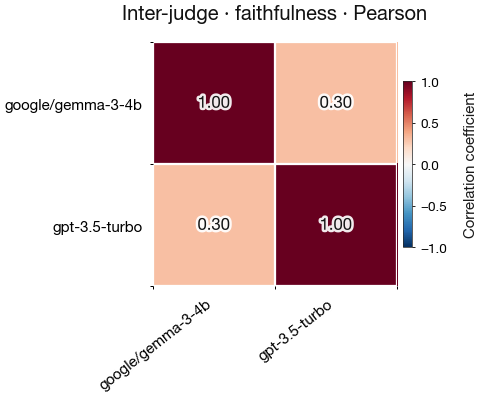

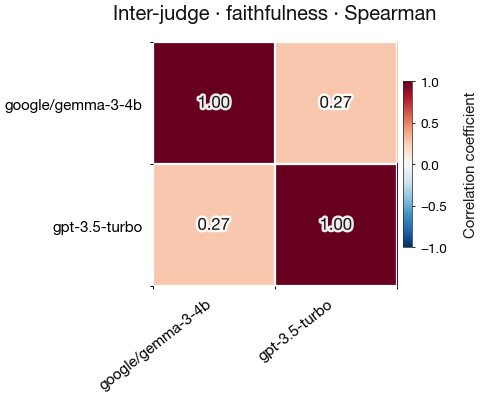

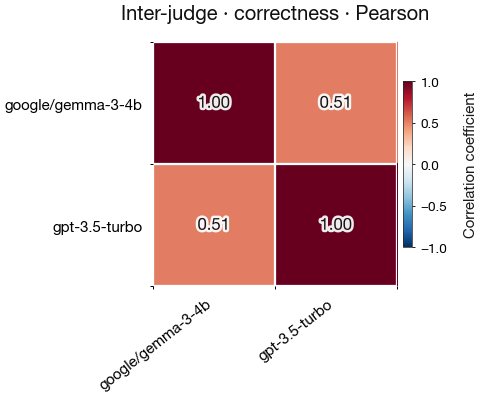

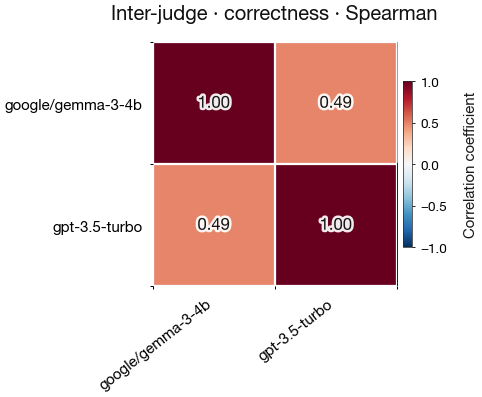

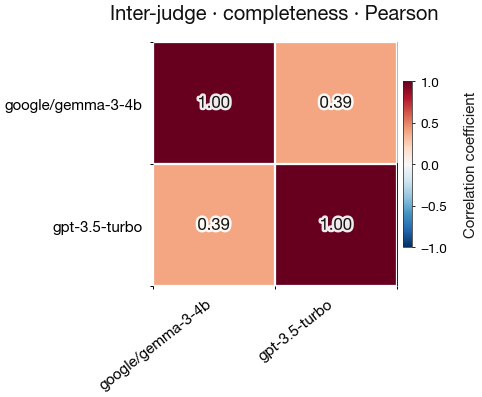

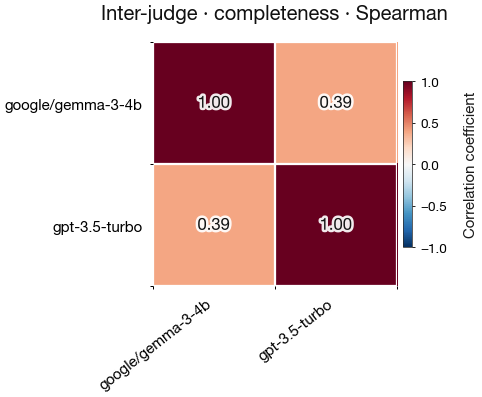

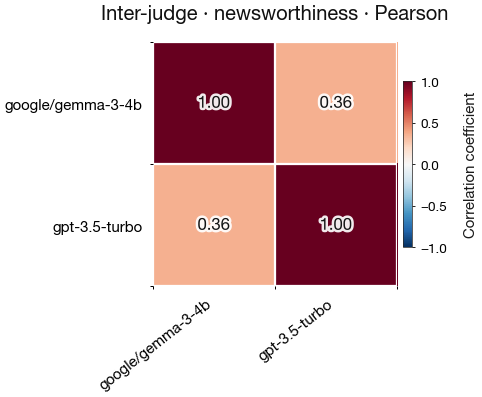

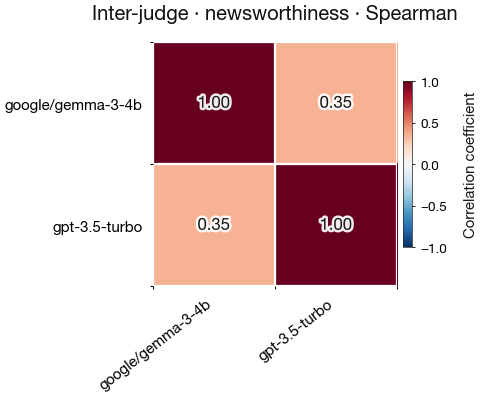

In [38]:
def corr_matrix_for_subset(wide: pd.DataFrame, method: str) -> pd.DataFrame:
    return wide.corr(method=method)


inter_judge_results: dict[str, dict[str, pd.DataFrame]] = {}

for dim in DIMENSIONS:
    sub = long_df.loc[long_df["dimension"] == dim].copy()
    if sub.empty:
        print(f"{dim}: no rows")
        continue
    sub["cmp"] = sub.apply(comparison_key_inter_judge, axis=1)
    wide = sub.pivot_table(index="cmp", columns="judge", values="score", aggfunc="first")
    # keep rows observed by all judges
    wide = wide.dropna(axis=0, how="any")
    n = len(wide)
    print(f"{dim}: n = {n} paired judgments across all judges")
    if n < 3:
        print(f"  skip correlation (need >= 3 rows)")
        continue
    inter_judge_results[dim] = {
        "pearson": corr_matrix_for_subset(wide, "pearson"),
        "spearman": corr_matrix_for_subset(wide, "spearman"),
    }
    display(inter_judge_results[dim]["pearson"].style.format("{:.3f}").set_caption(f"{dim} — Pearson"))
    display(inter_judge_results[dim]["spearman"].style.format("{:.3f}").set_caption(f"{dim} — Spearman"))

for dim, mats in inter_judge_results.items():
    plot_correlation_matrix(mats["pearson"], f"Inter-judge · {dim} · Pearson")
    plot_correlation_matrix(mats["spearman"], f"Inter-judge · {dim} · Spearman")

## 2. Inter-dimension correlation (within each judge)

Same comparison must exist for **every** dimension in the tuple (complete cases only).

google/gemma-3-4b: n = 226 comparisons with all dimensions


dimension,faithfulness,correctness,completeness,newsworthiness
dimension,,,,
faithfulness,1.000,0.651,0.419,0.195
correctness,0.651,1.000,0.524,0.237
completeness,0.419,0.524,1.000,0.363
newsworthiness,0.195,0.237,0.363,1.000


dimension,faithfulness,correctness,completeness,newsworthiness
dimension,,,,
faithfulness,1.000,0.648,0.422,0.178
correctness,0.648,1.000,0.525,0.205
completeness,0.422,0.525,1.000,0.351
newsworthiness,0.178,0.205,0.351,1.000


gpt-3.5-turbo: n = 160 comparisons with all dimensions


dimension,faithfulness,correctness,completeness,newsworthiness
dimension,,,,
faithfulness,1.000,0.815,0.710,0.474
correctness,0.815,1.000,0.784,0.505
completeness,0.710,0.784,1.000,0.585
newsworthiness,0.474,0.505,0.585,1.000


dimension,faithfulness,correctness,completeness,newsworthiness
dimension,,,,
faithfulness,1.000,0.816,0.711,0.468
correctness,0.816,1.000,0.784,0.501
completeness,0.711,0.784,1.000,0.587
newsworthiness,0.468,0.501,0.587,1.000


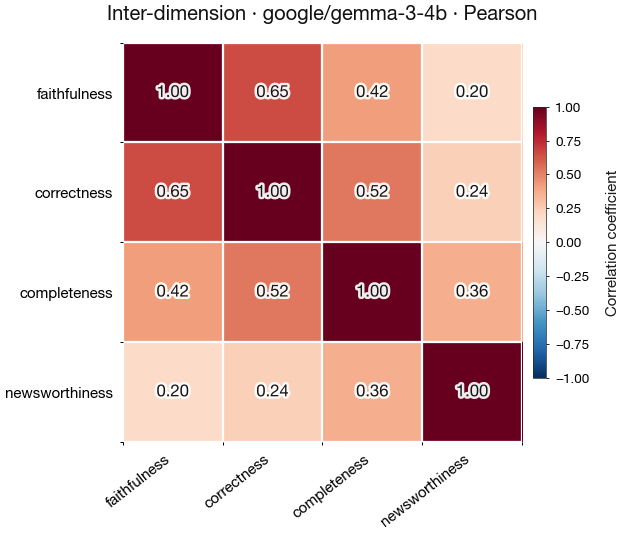

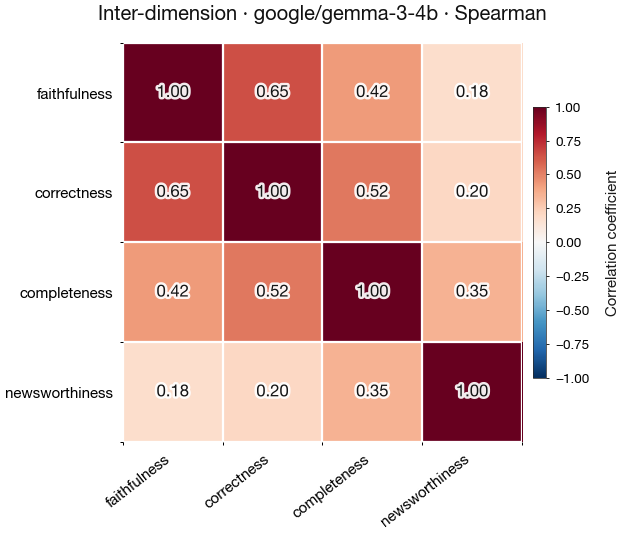

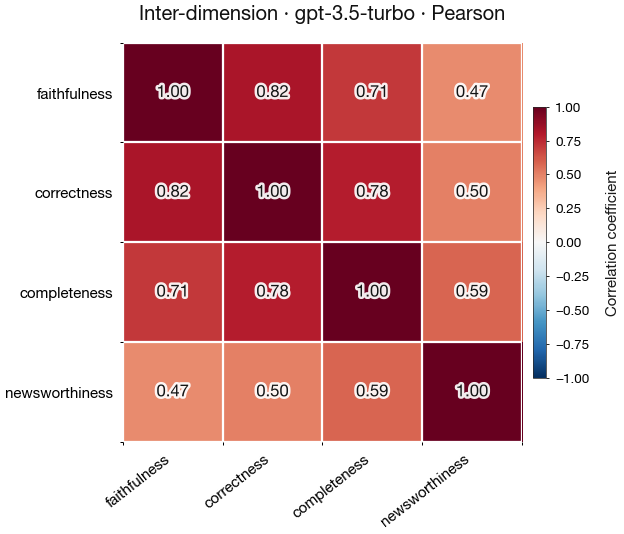

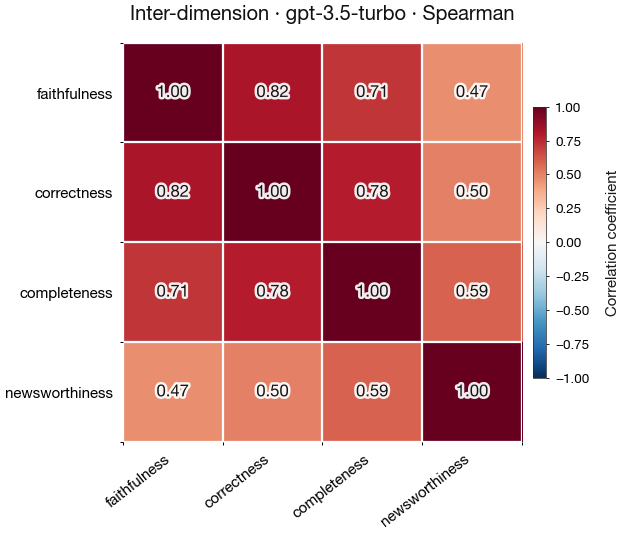

In [39]:
inter_dimension_results: dict[str, dict[str, pd.DataFrame]] = {}

for judge in JUDGES_USED:
    sub = long_df.loc[long_df["judge"] == judge].copy()
    if sub.empty:
        print(f"{judge}: no rows")
        continue
    sub["cmp"] = sub.apply(comparison_key_inter_dimension, axis=1)
    wide = sub.pivot_table(index="cmp", columns="dimension", values="score", aggfunc="first")
    wide = wide.reindex(columns=list(DIMENSIONS))
    wide = wide.dropna(axis=0, how="any")
    n = len(wide)
    print(f"{judge}: n = {n} comparisons with all dimensions")
    if n < 3:
        print("  skip correlation")
        continue
    inter_dimension_results[judge] = {
        "pearson": corr_matrix_for_subset(wide, "pearson"),
        "spearman": corr_matrix_for_subset(wide, "spearman"),
    }
    display(
        inter_dimension_results[judge]["pearson"].style.format("{:.3f}").set_caption(
            f"{judge} — Pearson (dimensions)"
        )
    )
    display(
        inter_dimension_results[judge]["spearman"].style.format("{:.3f}").set_caption(
            f"{judge} — Spearman (dimensions)"
        )
    )

for judge, mats in inter_dimension_results.items():
    plot_correlation_matrix(
        mats["pearson"],
        f"Inter-dimension · {_short_label(judge)} · Pearson",
    )
    plot_correlation_matrix(
        mats["spearman"],
        f"Inter-dimension · {_short_label(judge)} · Spearman",
    )



## 3. Optional: single table — mean inter-judge Pearson by dimension

Off-diagonal entries only (unique judge pairs).

,dimension,mean_pearson_judge_pairs,n_pairs
0,faithfulness,0.298777,1
1,correctness,0.509750,1
2,completeness,0.393678,1
3,newsworthiness,0.357666,1


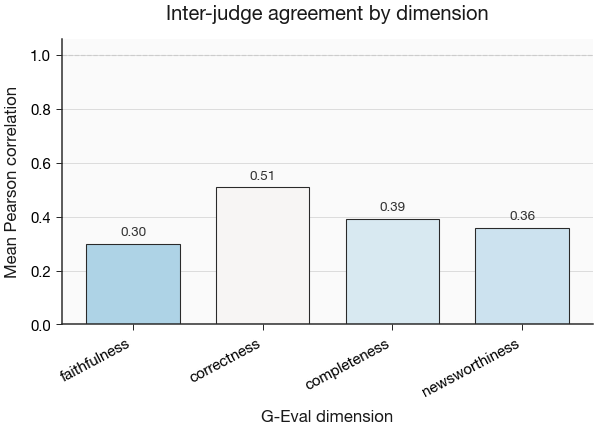

In [40]:
summary_rows = []
for dim, mats in inter_judge_results.items():
    cm = mats["pearson"]
    judges_l = list(cm.columns)
    pairs = []
    for i, a in enumerate(judges_l):
        for b in judges_l[i + 1 :]:
            pairs.append(cm.loc[a, b])
    if pairs:
        summary_rows.append(
            {"dimension": dim, "mean_pearson_judge_pairs": float(np.mean(pairs)), "n_pairs": len(pairs)}
        )

summary_df = pd.DataFrame(summary_rows) if summary_rows else pd.DataFrame()
display(summary_df)

if not summary_df.empty and "mean_pearson_judge_pairs" in summary_df.columns:
    dims = summary_df["dimension"].astype(str).tolist()
    vals = summary_df["mean_pearson_judge_pairs"].to_numpy(dtype=float)
    n_b = len(dims)
    fig_w = min(7.8, max(5.2, 0.55 * n_b + 3.0))
    fig, ax = plt.subplots(figsize=(fig_w, 3.8))
    x = np.arange(n_b)
    colors = plt.cm.RdBu_r(0.12 + 0.76 * vals)
    bars = ax.bar(
        x,
        vals,
        color=colors,
        edgecolor="#2a2a2a",
        linewidth=0.65,
        width=0.72,
        zorder=2,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(dims, rotation=28, ha="right", fontsize=9)
    ax.set_ylabel("Mean Pearson correlation", fontsize=10, labelpad=6)
    ax.set_xlabel("G-Eval dimension", fontsize=10, labelpad=6)
    ax.set_title(
        "Inter-judge agreement by dimension",
        fontsize=12,
        fontweight="600",
        pad=12,
    )
    ymax = float(np.nanmax(vals)) if np.any(np.isfinite(vals)) else 1.0
    ax.set_ylim(0, max(1.06, ymax + 0.14))
    ax.axhline(1.0, color="#cccccc", linewidth=0.7, linestyle="--", zorder=1)
    ax.yaxis.grid(True, linestyle="-", linewidth=0.45, alpha=0.35, color="#888888")
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for b, v in zip(bars, vals):
        if np.isfinite(v):
            ax.text(
                b.get_x() + b.get_width() / 2.0,
                b.get_height() + 0.02,
                f"{v:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="#333333",
            )
    fig.tight_layout()
    if SAVE_FIGURES:
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            FIGURES_DIR / "mean_inter_judge_pearson_by_dimension.png",
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
        )
    plt.show()